# **CASO 3: Hay un Jupyter que lo explica**

Intregrantes de ***Hay un Jupyter Notebook que lo explica***:
- **Fabián Maldonado** 201973116-5
- **Nayely Pérez** 202173124-5
- **Franco Salgado** 202073058-k
- **Kevin Vega** 202073064-4

[Video]https://youtu.be/a7WMRSp8Sms

[Canva] https://www.canva.com/design/DAG6eX2fmmw/uOKgG64wcV4E8YM7J0HsRg/edit?utm_content=DAG6eX2fmmw&utm_campaign=designshare&utm_medium=link2&utm_source=sharebutton

[Github]

# 1) Inteligencia:
## Métricas de desempeño:
La detección de las expresiones faciales en mangas debe ser correcta más de 85% veces. Es decir de un ocurracy igual o mayor a 85%. Para evitar el overfitting(que el modelo se ajuste demasiado a los datos de entrenamiento) nuestro ocurracy es de 85% para arriba.
Si tengo 100 imágenes de expresiones de personajes de manga, detectará bien las expresiones de 85 de las imágenes y el resto no necesariamente lo detectará correctamente.
## Alcance:
Identificar con alta precisión las expresiones de personajes de mangas.

# 2) Proceso empresarial:
## Estratégico:
- La estrategia escogida es la de **soluciones para los clientes**, ya que se busca ofrecer una alternativa de accesibilidad para personas no videntes innovadora enfocada en el manga mediante un sistema automatizado que genere una descripción adecuada que le transmita al cliente la intencionalidad del dibujante por medio de la oralidad.
- Este producto debe ofrecer un **servicio de calidad** que no empañe a la obra original, es decir, debe ser preciso y eficiente, evitando malinterpretar los mensajes que deseaba expresar el autor a través de sus dibujos. De lo contrario, la herramienta se vería como una molesta más que una ayuda, provocando su eventual abandono de uso y mantención.

## Operativo:
- El producto de IA se integrará en plataformas o aplicaciones de manga que proporcionen contenido accesible para personas no videntes. Este producto se utilizará en un sistema que permita leer mangas y describir las expresiones faciales de los personajes por cada panel de la historia. La IA identificará las expresiones faciales de los personajes en el manga y generará un texto alternativo descriptivo que se reproducirá de forma oral que ayudará a los usuarios a comprender el estado emocional de los personajes en cada panel.
- El sistema funcionará de manera automática, si el usuario activa la opción. Cuando el usuario selecciona un manga para leer, la plataforma procesará las imágenes y aplicará el modelo entrenado para generar las descripciones de las expresiones faciales que se encuentran en los paneles, las cuales podrán ser reproducidas y escuchadas por el usuario.

# 3) Tecnología de la IA:
## Propiedad intelectual(PI):

* Se utilizarán datos recopilados por datasets con imágenes de distintos manga y animes, por lo que los datos utilizados se encuentran protegidos por copyright de distintas revistas y estudios japoneses. El modelo no es generativo, pero se entrenó con creaciones artísticas de terceros.
* Al utilizar estos conjuntos de datos, pese a haberse obtenido de un dataset público, puede generar problemas legales por copyright, en Chile está la ley 17.336 que además protege a creaciones del extrangero.
* Para los propósitos buscados por nuestro equipo, nos beneficia en la imagen pública tener nuestro código open-source pues queremos ayudar a las personas no videntes.
## Abordaje de datos (GAFAN):
* Los datos fueron adquiridos por datasets en universe.roboflow.com, con datos entre 1000 y 3000 muestras de diferentes mangas y animes. Los datasets no especifican si los datos fueron obtenidos con permiso de los dueños intelectuales de las obras, por lo que asumimos que fueron recortes obtenidos directamente de las creaciones originales.

# 4) Proceso de cambio:
## Desarrollo de Software:
- **Versionamiento y control:** Se utilizará control de versiones (Git) para el código del modelo, los datos etiquetados y las configuraciones de entrenamiento. Se crearán ramas específicas para experimentar.
- **Plan de pruebas y experimentos:** Evaluación de la integración entre la plataforma de lectura, el servicio de IA y la herramienta que vocaliza la interpretación del modelo. Validación del $\texttt{accuracy} \geq 85%$ sobre expresiones básicas ($\texttt{Angry}$, $\texttt{Embarrassed}$, $\texttt{Happy}$, $\texttt{Psyco-Crazy}$, $\texttt{Sad}$ y $\texttt{Scared}$). Detección de nuevas versiones de modelos pre-entrenados o técnicas de visión que mejoren la precisión en rostros no realistas.
- **Análisis de ROI:** Evaluación del impacto del sistema en el acceso a contenido para personas no videntes.
- **Sesiones UX/UI:** Se realizarán sesiones con usuarios no videntes para evaluar: La claridad de las descripciones generadas. La velocidad y tono de la conversión texto-a-voz. Cómo integrar los mensajes sin interrumpir la lectura del manga.
- **Metodologías ágiles:** Uso de Scrum con *sprints* semanales.
- **Control del presupuesto:** Revisión del consumo de GPU durante entrenamiento, costos del almacenamiento del *dataset* y costos de APIs de texto-a-voz.

## Cánceres de la IA:
- **Malversación de datos:** Los modelos podrían ser vulnerables a imágenes manipuladas digitalmente.
  - Mitigación: Uso de *datasets* controlado.
- **Falta de generalización:** Los estilos de dibujo manga varían mucho entre autores.
  - Mitigación: Recolectar imágenes con distintas expresiones, sombreados, proporciones exageradas, etc. Re-entrenamiento periódico para mantener el modelo actualizado a nuevos mangas.
- **Sesgos:** El modelo podría interpretar mejor expresiones en ciertos estilos de dibujo que en otros.
  - Mitigación: Balancear el *dataset* según estilos, géneros (*shonen*, *shojo*, *seinen*), épocas y niveles de detalle.
- **Comportamiento no deseado:** Mal rendimiento, detectar expresiones incorrectas o ambiguas.
  - Mitigación: Supervisión interna para que el sistema responda con "expresión no determinada" en lugar de inventar una emoción.

MODELO

In [45]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
from tqdm.notebook import tqdm
%matplotlib inline
import tensorflow as tf 
from sklearn.metrics import confusion_matrix
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.preprocessing.image import load_img, img_to_array
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
from sklearn.preprocessing import LabelEncoder
import random

In [2]:
TRAIN_DIR =  "RoboAnimeProject.v7-version-7.folder/train"
TEST_DIR = "RoboAnimeProject.v7-version-7.folder/test"

In [3]:
def load_dataset(directory):
    image_paths = []
    labels = []

    for label in os.listdir(directory):
        label_path = os.path.join(directory, label)
        if not os.path.isdir(label_path):
            continue
        for filename in os.listdir(label_path):
            image_path = os.path.join(directory, label, filename)
            image_paths.append(image_path)
            labels.append(label)
        
        print(label, "Completed")
    return image_paths, labels




In [4]:
train = pd.DataFrame()
train['image'],train['label'] = load_dataset(TRAIN_DIR)

#Shuffle the dataset

train = train.sample(frac=1).reset_index(drop=True)

test = pd.DataFrame()
test['image'],test['label'] = load_dataset(TEST_DIR)

#Shuffle the dataset

test = test.sample(frac=1).reset_index(drop=True)



Happy Completed
Sad Completed
Psyco - Crazy Completed
Angry Completed
Embarrassed Completed
Scared Completed
Happy Completed
Sad Completed
Psyco - Crazy Completed
Angry Completed
Embarrassed Completed
Scared Completed


<Axes: xlabel='count', ylabel='label'>

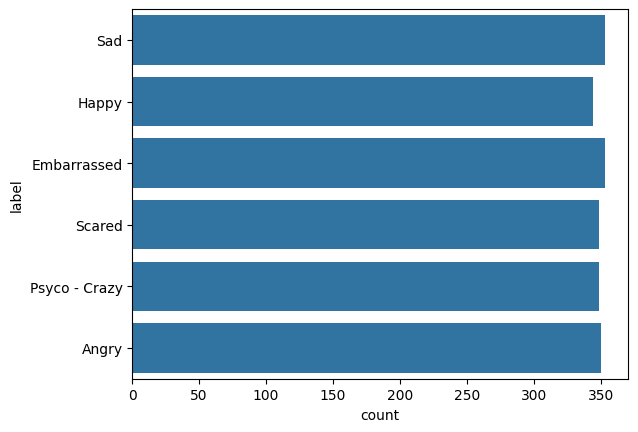

In [5]:
sns.countplot(train['label'])

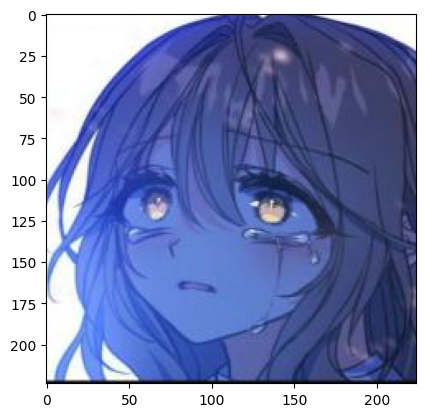

In [59]:
from PIL import Image
img= Image.open(train['image'][80])
plt.imshow(img)

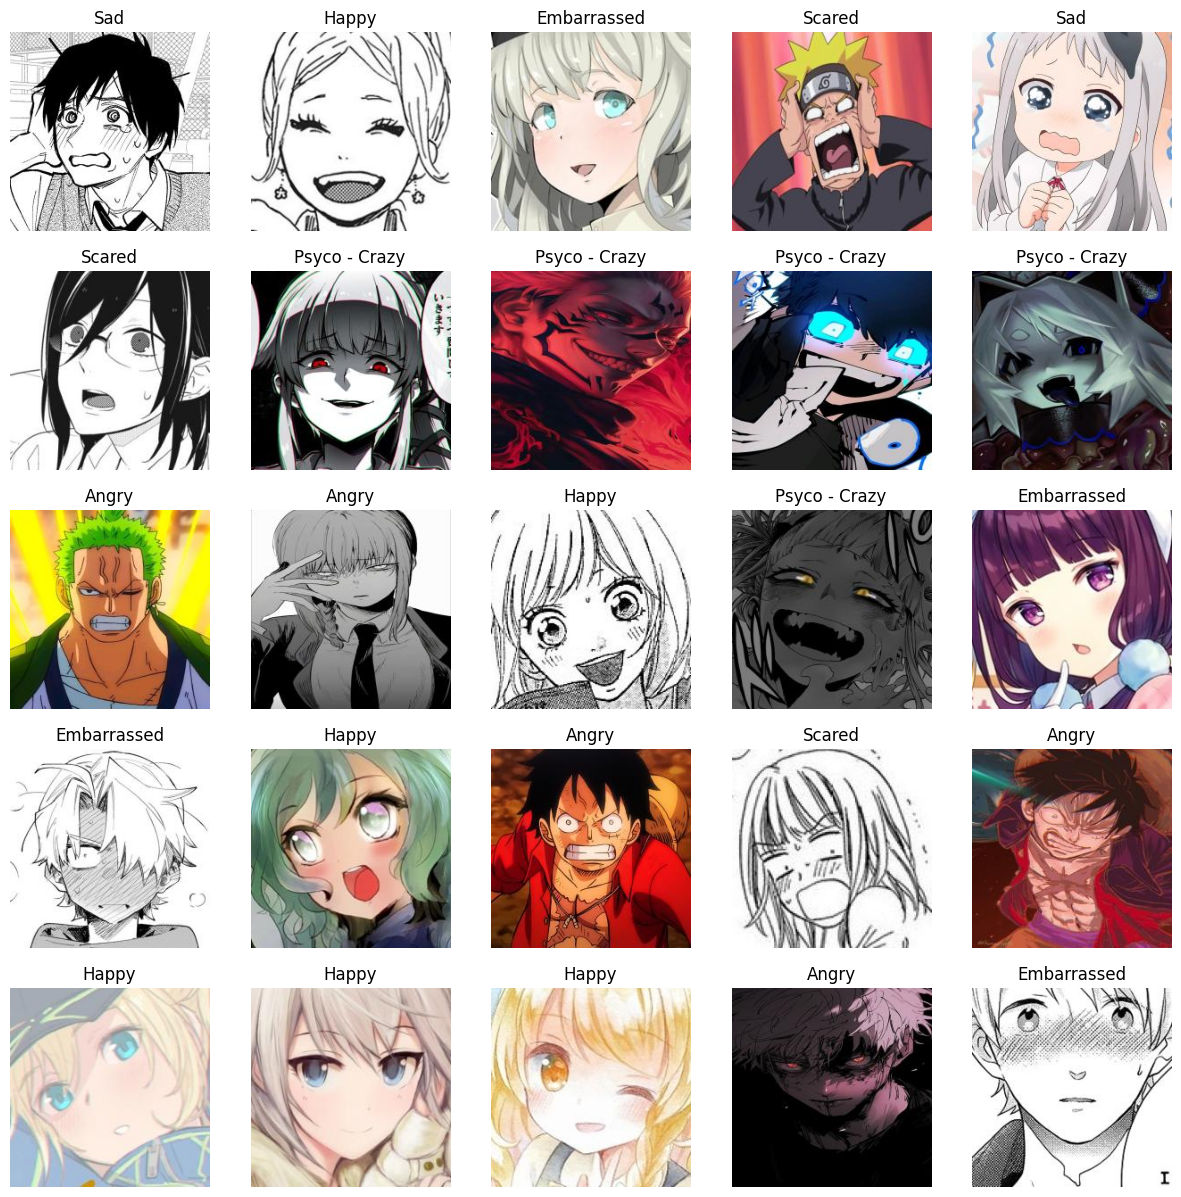

In [56]:
plt.figure(figsize=(15,15))
files = train.iloc[:25]

for index, file, label in files.itertuples():
    plt.subplot(5,5,index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

In [8]:
def extract_features(images):
    features = []

    for image in tqdm(images):
        img = load_img(
            image,
            target_size=(128, 128),
            color_mode='rgb'
        )
        img = img_to_array(img)
        img = img / 255.0  # opcional: normalización
        features.append(img)

    features = np.array(features)
    return features

In [9]:
train_features = extract_features(train['image'])

  0%|          | 0/2098 [00:00<?, ?it/s]

In [10]:
test_features = extract_features(test['image'])

  0%|          | 0/293 [00:00<?, ?it/s]

In [11]:
## normalize the image
x_train = train_features
x_test = test_features

In [12]:
# laber to integer
le = LabelEncoder()
le.fit(train['label'])
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [13]:
y_train = to_categorical(y_train, num_classes=6)
y_test = to_categorical(y_test, num_classes=6)

In [14]:
#config
input_shape = (128,128,3)
num_classes = 6 

In [15]:
# MODEL
model = Sequential([
    # Bloque 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
    MaxPooling2D(pool_size=(2,2)),
    
    # Bloque 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    
    # Bloque 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    
    # Bloque 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    
    # Clasificación
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

# COMPILACIÓN
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(x=x_train, y=y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 213ms/step - accuracy: 0.2097 - loss: 1.7521 - val_accuracy: 0.3072 - val_loss: 1.6541
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 217ms/step - accuracy: 0.2912 - loss: 1.6036 - val_accuracy: 0.3720 - val_loss: 1.5086
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 213ms/step - accuracy: 0.3089 - loss: 1.5488 - val_accuracy: 0.3891 - val_loss: 1.4770
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/step - accuracy: 0.3394 - loss: 1.4831 - val_accuracy: 0.3140 - val_loss: 1.4591
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - accuracy: 0.3861 - loss: 1.3907 - val_accuracy: 0.4164 - val_loss: 1.4113
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 245ms/step - accuracy: 0.3904 - loss: 1.3859 - val_accuracy: 0.4505 - val_loss: 1.3625
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 227ms/step - accuracy: 0.4028 - loss: 1.3336 - val_accuracy: 0.4334 - val_loss: 1.3694
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 223ms/step - accuracy: 0.4256 - loss: 1.2929 - val_accu

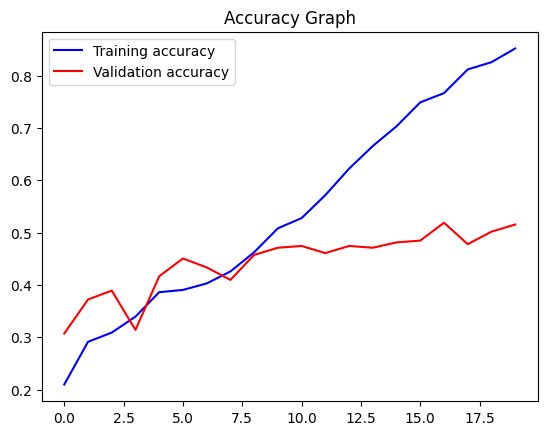

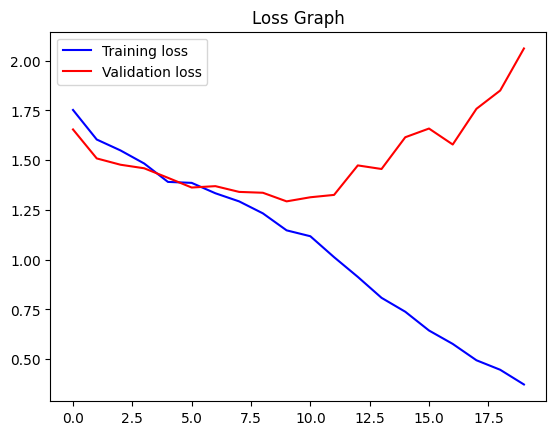

In [62]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.show()

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Loss Graph')
plt.legend()

plt.show()


Original Output: Sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Predicted Output: Psyco - Crazy


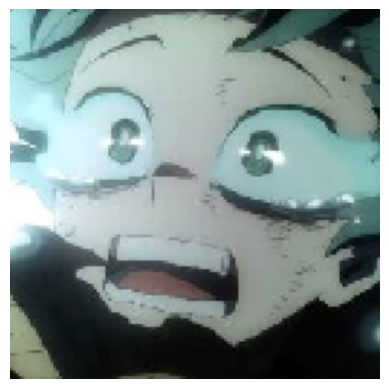

In [67]:
image_index = random.randint(0, len(test) - 1)

print("Original Output:", test['label'][image_index])

# la imagen ya es (128,128,3)
img = x_test[image_index]

pred = model.predict(img.reshape(1, 128, 128, 3))
prediction_label = le.inverse_transform([pred.argmax()])[0]

print("Predicted Output:", prediction_label)

plt.imshow(img)           # NO usar cmap
plt.axis('off')
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


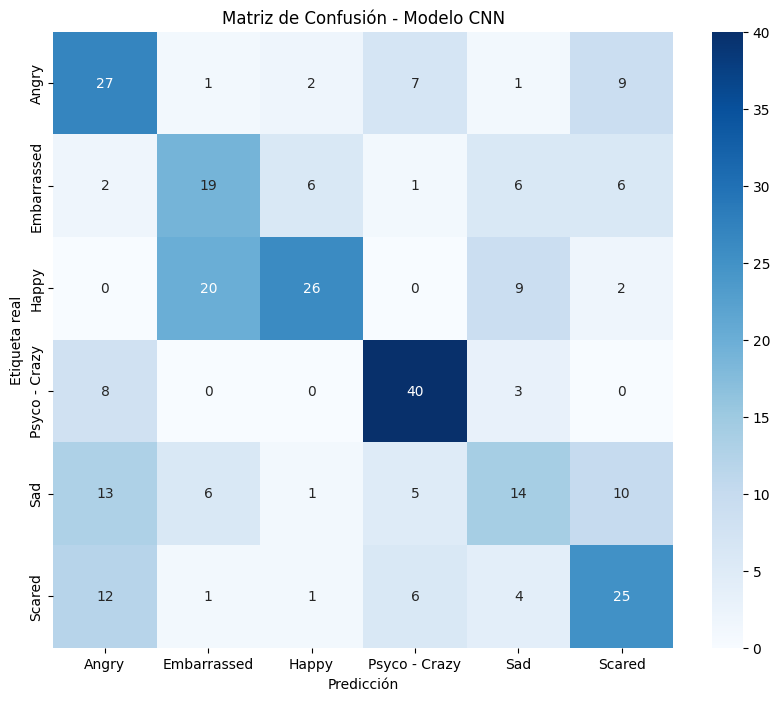

In [49]:
# Predicciones del modelo (probabilidades)
y_pred_probs = model.predict(x_test)

# Convertir probabilidades a clase (argmax)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convertir y_test one-hot a clase
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión - Modelo CNN")
plt.show()